In [1]:
import os
import random
import json
import cv2
import onnx
import numpy as np
import time
import torch
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from pycocotools import mask as maskUtils
import onnxruntime as ort
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from onnxruntime.quantization import (
    CalibrationDataReader,
    quantize_static,
    QuantType,
    QuantFormat
)

from rfdetr import RFDETRSegPreview

c:\Users\vishn\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\vishn\AppData\Local\Programs\Python\Python312\Lib\site-packages\rfdetr\models\weights.py:258: FutureWarning: target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
  @deprecated(target=True, args_mapping={"train_config": None}, deprecated_in="1.7.0", remove_in="1.9.0", num_warns=-1)


In [2]:
model = RFDETRSegPreview(pretrain_weights=r"C:\Users\vishn\Downloads\WBC\outputs\output\checkpoint_best_regular.pth", device="cpu")
model.optimize_for_inference()

TEST_DIR = Path(r"C:\Users\vishn\Downloads\WBC\TEST_MIXED")

image_paths = list(TEST_DIR.glob("*.jpg"))

print("Total images: ", len(image_paths))

random.seed(42)
sample_images = random.sample(image_paths, min(1, len(image_paths)))

C:\Users\vishn\AppData\Local\Temp\ipykernel_26100\2409805241.py:1: FutureWarning: The `RFDETRSegPreview` was deprecated since v1.7.0. It will be removed in v2.0.0.
  model = RFDETRSegPreview(pretrain_weights=r"C:\Users\vishn\Downloads\WBC\outputs\output\checkpoint_best_regular.pth", device="cpu")
[2026-07-12 14:09:26] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-12 14:09:26] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-12 14:09:27] [WARNING] rf-detr - Checkpoint has 10 classes but model is configured for 90. Using checkpoint class count (10). Pass num_classes=10 to suppress this warning.
[2026-07-12 14:09:27] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckp

Total images:  140


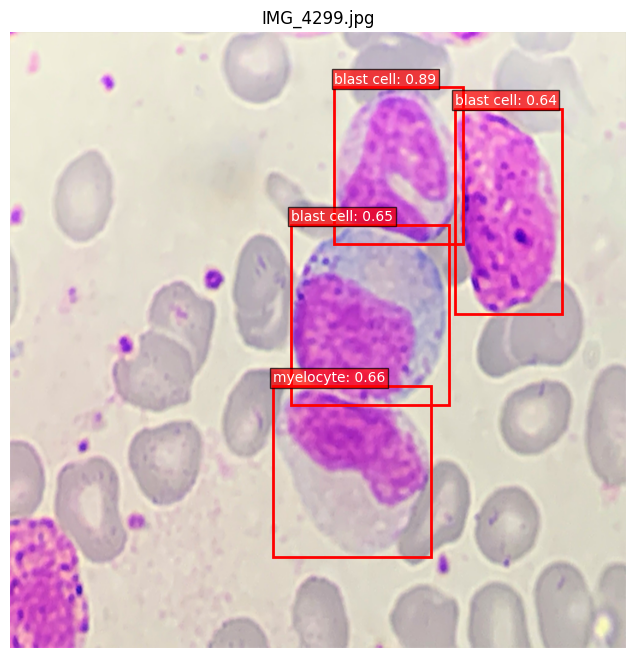

In [15]:

import supervision as sv
for img_path in sample_images:
    image = Image.open(img_path).convert("RGB")
    image = image.resize((720,720))
    result = model.predict(image)
    
    # Plot image
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)

    # Draw predictions
    for box, score, cls_name in zip(
        result.xyxy,
        result.confidence,
        result.data["class_name"]
    ):
        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            max(y1 - 5, 5),
            f"{cls_name}: {score:.2f}",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.7, pad=2)
        )

    ax.set_title(img_path.name)
    ax.axis("off")
    plt.show()

In [4]:
img = os.path.join(r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images",
                   os.listdir(r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images")[0])

result = model.predict(img)

print(type(result))
print(result)
print(dir(result))

<class 'supervision.detection.core.Detections'>
Detections(xyxy=array([[ 19.714645, 160.97034 ,  73.70804 , 236.1836  ]], dtype=float32), mask=array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(1, 256, 256)), confidence=array([0.92619383], dtype=float32), class_id=array([0]), tracker_id=None, data={'source_image': array([[[203, 208, 185],
        [203, 208, 186],
        [207, 211, 196],
        ...,
        [200, 201, 185],
        [199, 200, 184],
        [197, 198, 182]],

       [[206, 209, 188],
        [204, 209, 189],
        [207, 211, 196],
        ...,
        [200, 201, 185],
        [198, 199, 183],
        [197, 198, 182]],

       [[208, 209, 191],
        [2

In [5]:
def generate_predictions_json(model, coco_json_path, image_folder, output_json="predictions.json", score_threshold=0.25):

    with open(coco_json_path, "r") as f:
        coco = json.load(f)

    predictions = []

    for image_info in tqdm(coco["images"]):

        image_path = os.path.join(
            image_folder,
            os.path.basename(image_info["file_name"])
        )

        detections = model.predict(image_path)

        if len(detections.xyxy) == 0:
            continue

        for i in range(len(detections.xyxy)):

            score = float(detections.confidence[i])

            if score < score_threshold:
                continue

            mask = detections.mask[i].astype(np.uint8)

            rle = maskUtils.encode(np.asfortranarray(mask))

            rle["counts"] = rle["counts"].decode("utf-8")

            predictions.append({
                "image_id": image_info["id"],
                "category_id": int(detections.class_id[i]) + 1,
                "score": score,
                "segmentation": rle
            })

    with open(output_json, "w") as f:
        json.dump(predictions, f)

    print(f"Saved {len(predictions)} predictions to {output_json}")

In [6]:
generate_predictions_json(
    model=model,
    coco_json_path=r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json",
    image_folder=r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images",
    output_json="predictions.json",
    score_threshold=0.25
)

100%|██████████| 117/117 [01:04<00:00,  1.81it/s]

Saved 154 predictions to predictions.json


In [5]:
def compute_map(gt_json_path, pred_json_path):
    """
    Computes Segmentation mAP.

    Args:
        gt_json_path (str): Path to COCO ground truth annotations.json
        pred_json_path (str): Path to COCO predictions.json

    Returns:
        float: mAP
    """

    coco_gt = COCO(gt_json_path)

    # Fix missing COCO fields
    if "info" not in coco_gt.dataset:
        coco_gt.dataset["info"] = {}

    if "licenses" not in coco_gt.dataset:
        coco_gt.dataset["licenses"] = []

    coco_dt = coco_gt.loadRes(pred_json_path)

    evaluator = COCOeval(coco_gt, coco_dt, iouType="segm")

    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()
    
    map50_95 = evaluator.stats[0]   # AP@[IoU=0.50:0.95]
    map50 = evaluator.stats[1]      # AP@0.50

    return map50, map50_95

In [6]:
map50, map50_95 = compute_map(
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json",
    r"C:\Users\vishn\Downloads\WBC\predictions.json"
)

print(f"Segmentation mAP@50    : {map50:.4f}")
print(f"Segmentation mAP@50:95 : {map50_95:.4f}")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.834
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.853
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.853
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.869
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.744
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.871
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe

In [10]:
onnx_map50, onnx_map50_95 = compute_map(
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json",
    r"C:\Users\vishn\Downloads\WBC\predictions_fp32.json"
)

print(f"Segmentation mAP@50    : {onnx_map50:.4f}")
print(f"Segmentation mAP@50:95 : {onnx_map50_95:.4f}")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.09s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.834
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.853
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.853
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.869
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.744
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.871
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe

In [15]:
def load_masks_and_classes(gt_json_path, pred_json_path):

    coco_gt = COCO(gt_json_path)

    with open(pred_json_path, "r") as f:
        predictions = json.load(f)

    gt_masks = []
    gt_classes = []

    pred_masks = []
    pred_classes = []

    # ---------- Ground Truth ----------
    for ann in coco_gt.dataset["annotations"]:

        mask = coco_gt.annToMask(ann)

        gt_masks.append(mask.astype(bool))
        gt_classes.append(ann["category_id"])

    # ---------- Predictions ----------
    for pred in predictions:

        mask = maskUtils.decode(pred["segmentation"])

        pred_masks.append(mask.astype(bool))
        pred_classes.append(pred["category_id"])

    return gt_masks, gt_classes, pred_masks, pred_classes

In [11]:
gt_masks, gt_classes, pred_masks, pred_classes = load_masks_and_classes(
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json",
    r"C:\Users\vishn\Downloads\WBC\predictions.json"
)

print(len(gt_masks))
print(len(pred_masks))

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
145
154


In [17]:
onnx_gt_masks, onnx_gt_classes, onnx_pred_masks, onnx_pred_classes = load_masks_and_classes(
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json",
    r"C:\Users\vishn\Downloads\WBC\predictions_fp32_1.json"
)

print(len(onnx_gt_masks))
print(len(onnx_pred_masks))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
145
154


In [19]:
def mask_iou(mask1, mask2):
    """
    Compute IoU between two binary masks.
    """

    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)

    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0.0

    return intersection / union

In [20]:
def compute_mean_iou(gt_masks, gt_classes,
                     pred_masks, pred_classes,
                     iou_threshold=0.5):
    """
    Computes Mean IoU for segmentation.

    Returns
    -------
    mean_iou : float
    """

    matched_gt = set()
    ious = []

    for pred_mask, pred_cls in zip(pred_masks, pred_classes):

        best_iou = 0
        best_gt = -1

        for gt_idx, (gt_mask, gt_cls) in enumerate(zip(gt_masks, gt_classes)):

            if gt_idx in matched_gt:
                continue

            if gt_cls != pred_cls:
                continue

            iou = mask_iou(pred_mask, gt_mask)

            if iou > best_iou:
                best_iou = iou
                best_gt = gt_idx

        if best_iou >= iou_threshold:
            matched_gt.add(best_gt)
            ious.append(best_iou)

    if len(ious) == 0:
        return 0.0

    return float(np.mean(ious))

In [21]:
mean_iou = compute_mean_iou(
    gt_masks,
    gt_classes,
    pred_masks,
    pred_classes
)

print(f"Mean IoU: {mean_iou:.4f}")

Mean IoU: 0.9550


In [22]:
onnx_mean_iou = compute_mean_iou(
    onnx_gt_masks,
    onnx_gt_classes,
    onnx_pred_masks,
    onnx_pred_classes
)

print(f"Mean IoU: {onnx_mean_iou:.4f}")

Mean IoU: 0.9550


In [23]:
def compute_precision(pred_masks,
                      pred_classes,
                      gt_masks,
                      gt_classes,
                      iou_threshold=0.5):
    """
    Compute segmentation precision.

    Parameters
    ----------
    pred_masks : list of ndarray (HxW bool)
    pred_classes : list[int]

    gt_masks : list of ndarray
    gt_classes : list[int]

    Returns
    -------
    precision : float
    """

    matched_gt = set()

    TP = 0
    FP = 0

    for pred_mask, pred_cls in zip(pred_masks, pred_classes):

        best_iou = 0
        best_gt = -1

        for gt_idx, (gt_mask, gt_cls) in enumerate(zip(gt_masks, gt_classes)):

            if gt_idx in matched_gt:
                continue

            if pred_cls != gt_cls:
                continue

            iou = mask_iou(pred_mask, gt_mask)

            if iou > best_iou:
                best_iou = iou
                best_gt = gt_idx

        if best_iou >= iou_threshold:
            TP += 1
            matched_gt.add(best_gt)
        else:
            FP += 1

    if TP + FP == 0:
        return 0.0

    return TP / (TP + FP)

In [31]:
precision = compute_precision(
    pred_masks,
    pred_classes,
    gt_masks,
    gt_classes
)

print(f"Precision: {precision:.4f}")

Precision: 0.8766


In [25]:
onnx_precision = compute_precision(
    onnx_pred_masks,
    onnx_pred_classes,
    onnx_gt_masks,
    onnx_gt_classes
)

print(f"ONNX Precision: {onnx_precision:.4f}")

ONNX Precision: 0.8766


In [26]:
def compute_recall(pred_masks,
                   pred_classes,
                   gt_masks,
                   gt_classes,
                   iou_threshold=0.5):
    """
    Compute segmentation recall.

    Parameters
    ----------
    pred_masks : list of ndarray (HxW bool)
    pred_classes : list[int]

    gt_masks : list of ndarray
    gt_classes : list[int]

    Returns
    -------
    recall : float
    """

    matched_gt = set()

    TP = 0

    for pred_mask, pred_cls in zip(pred_masks, pred_classes):

        best_iou = 0
        best_gt = -1

        for gt_idx, (gt_mask, gt_cls) in enumerate(zip(gt_masks, gt_classes)):

            if gt_idx in matched_gt:
                continue

            if pred_cls != gt_cls:
                continue

            iou = mask_iou(pred_mask, gt_mask)

            if iou > best_iou:
                best_iou = iou
                best_gt = gt_idx

        if best_iou >= iou_threshold:
            TP += 1
            matched_gt.add(best_gt)

    FN = len(gt_masks) - TP

    if TP + FN == 0:
        return 0.0

    return TP / (TP + FN)

In [27]:
recall = compute_recall(
    pred_masks,
    pred_classes,
    gt_masks,
    gt_classes
)

print(f"Recall: {recall:.4f}")

Recall: 0.9310


In [28]:
onnx_recall = compute_recall(
    onnx_pred_masks,
    onnx_pred_classes,
    onnx_gt_masks,
    onnx_gt_classes
)

print(f"ONNX Recall: {onnx_recall:.4f}")

ONNX Recall: 0.9310


In [29]:
def compute_f1(precision, recall):
    """
    Compute F1-score from precision and recall.

    Parameters
    ----------
    precision : float
    recall : float

    Returns
    -------
    float
        F1-score
    """

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [32]:
f1 = compute_f1(precision, recall)

print(f"F1-score  : {f1:.4f}")

F1-score  : 0.9030


In [33]:
onnx_f1 = compute_f1(onnx_precision, onnx_recall)

print(f"F1-score  : {onnx_f1:.4f}")

F1-score  : 0.9030


In [34]:
def get_class_data(pred_masks,
                   pred_classes,
                   gt_masks,
                   gt_classes,
                   class_id):
    """
    Filter predictions and GT for a single class.
    """

    pred_masks_cls = []
    pred_classes_cls = []

    for mask, cls in zip(pred_masks, pred_classes):
        if cls == class_id:
            pred_masks_cls.append(mask)
            pred_classes_cls.append(cls)

    gt_masks_cls = []
    gt_classes_cls = []

    for mask, cls in zip(gt_masks, gt_classes):
        if cls == class_id:
            gt_masks_cls.append(mask)
            gt_classes_cls.append(cls)

    return (
        pred_masks_cls,
        pred_classes_cls,
        gt_masks_cls,
        gt_classes_cls
    )

In [35]:
with open(r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json", "r") as f:
    coco = json.load(f)

class_names = {
    cat["id"]: cat["name"]
    for cat in coco["categories"]
}

print(class_names)

{1: 'band cell', 2: 'basophil', 3: 'blast cell', 4: 'eosinophil', 5: 'lymphocyte', 6: 'monocyte', 7: 'neutrophil', 8: 'promyelocyte', 9: 'myelocyte', 10: 'metamyelocyte'}


In [36]:
for class_id, class_name in class_names.items():

    pred_masks_cls, pred_classes_cls, gt_masks_cls, gt_classes_cls = \
        get_class_data(
            pred_masks,
            pred_classes,
            gt_masks,
            gt_classes,
            class_id
        )

    precision = compute_precision(
        pred_masks_cls,
        pred_classes_cls,
        gt_masks_cls,
        gt_classes_cls
    )

    recall = compute_recall(
        pred_masks_cls,
        pred_classes_cls,
        gt_masks_cls,
        gt_classes_cls
    )

    f1 = compute_f1(precision, recall)

    mean_iou = compute_mean_iou(
        pred_masks_cls,
        pred_classes_cls,
        gt_masks_cls,
        gt_classes_cls
    )

    print(f"\n{class_name}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"Mean IoU  : {mean_iou:.4f}")


band cell
Precision : 0.6875
Recall    : 0.9167
F1-score  : 0.7857
Mean IoU  : 0.9687

basophil
Precision : 1.0000
Recall    : 0.8000
F1-score  : 0.8889
Mean IoU  : 0.9544

blast cell
Precision : 0.9677
Recall    : 1.0000
F1-score  : 0.9836
Mean IoU  : 0.9625

eosinophil
Precision : 0.8889
Recall    : 0.9412
F1-score  : 0.9143
Mean IoU  : 0.9673

lymphocyte
Precision : 0.8571
Recall    : 1.0000
F1-score  : 0.9231
Mean IoU  : 0.9596

monocyte
Precision : 0.9091
Recall    : 0.9091
F1-score  : 0.9091
Mean IoU  : 0.9762

neutrophil
Precision : 0.9565
Recall    : 1.0000
F1-score  : 0.9778
Mean IoU  : 0.9570

promyelocyte
Precision : 0.8462
Recall    : 1.0000
F1-score  : 0.9167
Mean IoU  : 0.9575

myelocyte
Precision : 0.8421
Recall    : 0.8421
F1-score  : 0.8421
Mean IoU  : 0.9163

metamyelocyte
Precision : 0.6000
Recall    : 0.5000
F1-score  : 0.5455
Mean IoU  : 0.9695


In [38]:
def benchmark_model(model, image_folder):

    image_files = [
        os.path.join(image_folder, f)
        for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    total_images = len(image_files)

    # Warm-up (not measured)
    for img in image_files[:5]:
        model.predict(img)

    start = time.perf_counter()

    for img in tqdm(image_files):
        model.predict(img)

    end = time.perf_counter()

    total_time = end - start

    latency = total_time / total_images          # seconds/image
    fps = total_images / total_time              # images/second
    throughput = fps                             # images/second

    print("=" * 40)
    print(f"Images        : {total_images}")
    print(f"Total Time    : {total_time:.4f} sec")
    print(f"Latency       : {latency*1000:.2f} ms/image")
    print(f"FPS           : {fps:.2f}")
    print(f"Throughput    : {throughput:.2f} images/sec")
    print("=" * 40)

    return latency, fps, throughput

In [45]:
latency, fps, throughput = benchmark_model(
    model,
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images"
)

100%|██████████| 117/117 [01:45<00:00,  1.11it/s]

Images        : 117
Total Time    : 105.3401 sec
Latency       : 900.34 ms/image
FPS           : 1.11
Throughput    : 1.11 images/sec


In [41]:
model_gpu = RFDETRSegPreview(
    pretrain_weights=r"C:\Users\vishn\Downloads\WBC\outputs\output\checkpoint_best_regular.pth",
    device="cuda"
)

model_gpu.optimize_for_inference()

image_folder = r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images"

image_files = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.endswith((".jpg", ".png", ".jpeg"))
]

for img in image_files[:10]:
    model_gpu.predict(img)

torch.cuda.synchronize()

start = time.perf_counter()

for img in tqdm(image_files):
    model_gpu.predict(img)

torch.cuda.synchronize()   # Wait for GPU to finish

end = time.perf_counter()

total_time = end - start
latency = total_time / len(image_files)
fps = len(image_files) / total_time
throughput = fps

print(f"Images       : {len(image_files)}")
print(f"Total Time   : {total_time:.4f} sec")
print(f"Latency      : {latency * 1000:.2f} ms/image")
print(f"FPS          : {fps:.2f}")
print(f"Throughput   : {throughput:.2f} images/sec")

[2026-07-06 19:57:06] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-06 19:57:06] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-06 19:57:07] [WARNING] rf-detr - Checkpoint has 10 classes but model is configured for 90. Using checkpoint class count (10). Pass num_classes=10 to suppress this warning.
100%|██████████| 117/117 [00:08<00:00, 13.55it/s]

Images       : 117
Total Time   : 8.6533 sec
Latency      : 73.96 ms/image
FPS          : 13.52
Throughput   : 13.52 images/sec
